In [32]:
import numpy as np
import torch
from typing import Dict, Any
import matplotlib.pyplot as plt
from model_ranking import (
    get_classification_dataloader,
    get_classification_TTA_loaders,
    ResNet,
    load_checkpoint_resnet,
    ClassificationModelConfig,
    ClassificationLoaderConfig,
    predict_with_features,
)

In [33]:
model_config: Dict[str, Any] = {
    "conv1": {
        "in_channels": 1,
        "out_channels": 64,
        "kernel_size": 7,
        "stride": 2,
        "padding": 3,
        "bias": False,
    },
    "out_channels":1,
    "modelname": "RN18_epfl80_aug5",
    "modelType": "ResNet18",
    "ckpt_path": "/g/kreshuk/talks/FineTuning/experiments/patch_classification/epfl/checkpoints/",
    "ckpt_key": "model_state",
    "feature_layers": [7,8]
}

model_cfg = ClassificationModelConfig.model_validate(model_config)

In [34]:
# Initialize model ONCE
model = ResNet(model_cfg)
device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")
model = load_checkpoint_resnet(
    model_cfg.modelname,
    model=model,
    path=str(model_cfg.ckpt_path),
    location="cpu",
    model_key="ResNet"
)
model = model.to(device)
_ = model.eval()  # Explicitly set to eval mode

/g/kreshuk/talks/model_ranking/src/model_ranking/classification/utils.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_locat

In [29]:
dataloader_config: Dict[str, Any] = {
    "patch_position": {
        "patch_pos_path": '/g/kreshuk/talks/data/epfl/classification_patches/epfl_resized_01_80x80.h5',
        "patch_pos_key": 'validation',
        "roi": None,
        "rnd_seed": None,
        "n_unique_patches": None
    },
    "aug_config": {
        "aug_rnd_seed": None,
        "transform_params": None,
        "raw_transform_params": [
            {"name": "RandomGamma", "p": 1, "params": {"alpha":[0.2,2]}}, 
            {"name": "RandomBrightness", "p": 1, "params": {"alpha": [0.0,0.3]}}
        ],
        "ndim": 2,
        "n_samples": None
    },
    "dataset": {
        "raw_path": "/scratch/talks/data/EPFL/val.h5",
        "raw_key": "raw",
        "mask_path": "/scratch/talks/data/EPFL/val.h5",
        "mask_key": "labels",
        "patch_shape": (1, 80, 80),
        "repeat_patches": False,
        "sample_patches": True,
        "patch_rnd_seed": 2,
        "mask_return_mode": False,
        "patch_return_mode": False,
    },
    "n_samples": 3,
    "ndim": 2,
    "batch_size": 1,
    "shuffle": False,
    "num_workers": 1
}
dataloader_cfg = ClassificationLoaderConfig.model_validate(dataloader_config)

In [30]:
dataloader = get_classification_dataloader(
    dataloader_cfg
)

number of unique patches loaded: 1271


In [31]:
print(len(dataloader.dataset))

3


In [26]:
dataloader.dataset[0][0].numpy().shape

(1, 80, 80)

In [27]:
np.all(np.equal(dataloader.dataset[0][0].numpy(), dataloader.dataset[2][0].numpy()))

False


=== Loop 1 ===
Sample 0
Raw shape: torch.Size([1, 1, 80, 80])


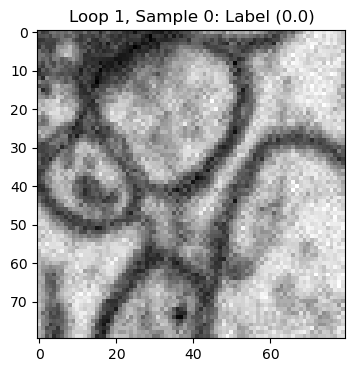

Sample 1
Raw shape: torch.Size([1, 1, 80, 80])


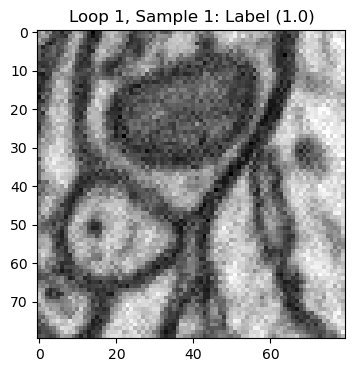

Sample 2
Raw shape: torch.Size([1, 1, 80, 80])


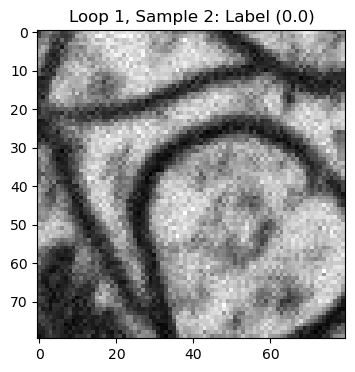


=== Loop 2 ===
Sample 0
Raw shape: torch.Size([1, 1, 80, 80])


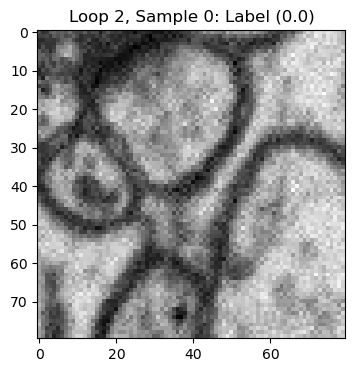

Sample 1
Raw shape: torch.Size([1, 1, 80, 80])


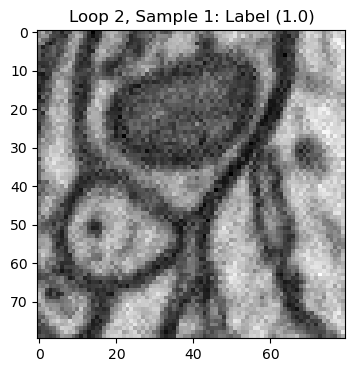

Sample 2
Raw shape: torch.Size([1, 1, 80, 80])


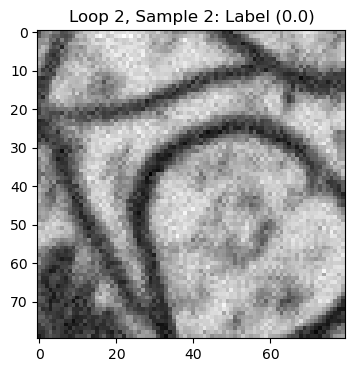


=== Loop 3 ===
Sample 0
Raw shape: torch.Size([1, 1, 80, 80])


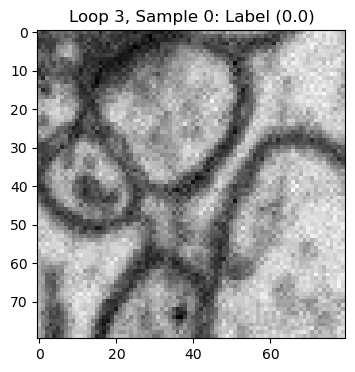

Sample 1
Raw shape: torch.Size([1, 1, 80, 80])


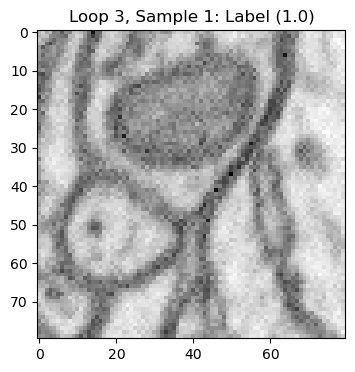

Sample 2
Raw shape: torch.Size([1, 1, 80, 80])


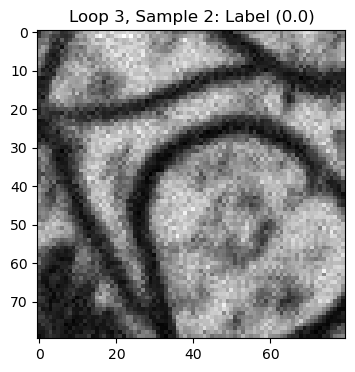

In [28]:
raws = [] 
for loop_num in range(3):
    print(f"\n=== Loop {loop_num + 1} ===")
    for i, (raw, label) in enumerate(dataloader):
        print(f"Sample {i}")
        print(f"Raw shape: {raw.shape}")
        
        plt.figure(figsize=(6, 4))
        _ = plt.imshow(raw.numpy().squeeze(), cmap='grey')
        _ = plt.title(f"Loop {loop_num + 1}, Sample {i}: Label ({label.numpy().squeeze()})")
        plt.show()
        
        raws.append(raw.numpy().copy())
        if i > 3:
            break

In [35]:
dataloader_config: Dict[str, Any] = {
    "patch_position": {
        "patch_pos_path": '/g/kreshuk/talks/data/epfl/classification_patches/epfl_resized_01_80x80.h5',
        "patch_pos_key": 'validation',
        "roi": None,
        "rnd_seed": None,
        "n_unique_patches": None
    },
    # "aug_config": None,
    "aug_config": {
        "aug_rnd_seed": 1,
        "transform_params": None,
        "raw_transform_params": [{"name": "RandomGamma", "p": 0.5, "params": {"alpha":[0.2,2]}}, {"name": "RandomBrightness", "p": 0.5, "params": {"alpha": [0.0,0.3]}}], #["AdditiveGaussianNoise", {"p": 0.15}, {"scale":[0.0,0.3]}]],
        "ndim": 2,
        "n_samples": 2
    },
    "dataset": {
        "raw_path": "/scratch/talks/data/EPFL/val.h5",
        "raw_key": "raw",
        "mask_path": "/scratch/talks/data/EPFL/val.h5",
        "mask_key": "labels",
        "patch_shape": (1, 80, 80),
        "repeat_patches": False,
        "sample_patches": True,
        "patch_rnd_seed": 2,
        "mask_return_mode": False,
        "patch_return_mode": False,
    },
    "n_samples": 3,
    "ndim": 2,
    "batch_size": 1,
    "shuffle": False,
    "num_workers": 1
}
dataloader_cfg = ClassificationLoaderConfig.model_validate(dataloader_config)

In [36]:
TTA_loaders = get_classification_TTA_loaders(
    dataloader_cfg
)

number of unique patches loaded: 1271


In [37]:
TTA_loaders

{'Gamma_a02-2': <torch.utils.data.dataloader.DataLoader at 0x7ffee4e24410>,
 'Brt_a00-03': <torch.utils.data.dataloader.DataLoader at 0x7ffee43a5a50>}

In [38]:
output = predict_with_features(
    model,
    TTA_loaders['Gamma_a02-2'],
    device=device,
    feature_layers=['ResNet.avgpool'],
)

100%|██████████| 3/3 [00:00<00:00,  7.16it/s]


In [39]:
output

{'predictions': array([6.2809460e-04, 9.9414223e-01, 2.6669273e-02], dtype=float32),
 'labels': array([0, 1, 0], dtype=int8),
 'features': {'ResNet.avgpool': array([[1.44163   , 1.4495144 , 1.3976008 , ..., 1.3175545 , 0.2797133 ,
          0.21407   ],
         [0.21757206, 0.51027006, 0.9388909 , ..., 1.1804534 , 1.6608096 ,
          1.4520773 ],
         [1.0116289 , 0.8701399 , 1.0653272 , ..., 1.3059922 , 0.4989201 ,
          0.38838965]], dtype=float32)}}


=== Loop 1 ===
Sample 0
Raw shape: torch.Size([1, 1, 80, 80])


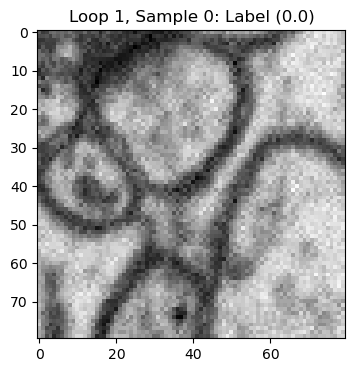

Sample 1
Raw shape: torch.Size([1, 1, 80, 80])


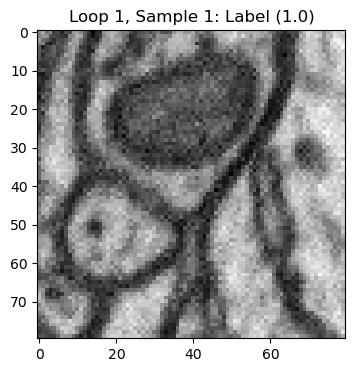

Sample 2
Raw shape: torch.Size([1, 1, 80, 80])


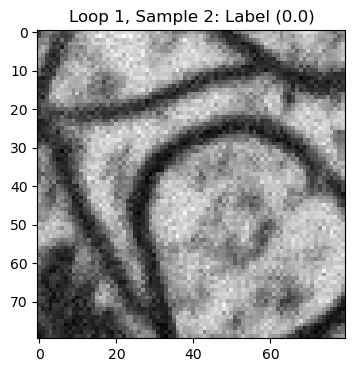

In [13]:
raws = [] 
for loop_num in range(1):
    print(f"\n=== Loop {loop_num + 1} ===")
    for i, (raw, label) in enumerate(TTA_loaders['Gamma_a02-2']):
        print(f"Sample {i}")
        print(f"Raw shape: {raw.shape}")
        
        plt.figure(figsize=(6, 4))
        _ = plt.imshow(raw.numpy().squeeze(), cmap='grey')
        _ = plt.title(f"Loop {loop_num + 1}, Sample {i}: Label ({label.numpy().squeeze()})")
        plt.show()
        
        raws.append(raw.numpy().copy())
        if i > 3:
            break